# RiMEA 11: Choice of Escape Route

A public space has 2 exits: Exit 1 and Exit 2. The space is occupied with 1000 agents from the left side with maximum possible density. The expected result is that the agents prefer the closer Exit 1 and congestion occurs in this area. However, individual persons will also use the alternative Exit 2.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 25 June 2026, 12:29 CEST


In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon
from shapely.plotting import plot_polygon
import jupedsim as jps
from jupedsim_scenarios import load_scenario, run_scenario, run_sweep
from shapely import wkt
import json
import sqlite3
import zipfile
import os

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load the Scenario

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Rimea-11-choice-escape.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-11-choice-escape.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         2
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~1000
    jps-distributions_0: 1000 agents


## Setup Simulation and Run

In [5]:
with zipfile.ZipFile(SCENARIO_ZIP, "r") as z:
    geo_wkt = z.read("geometry.wkt").decode("utf-8")
    cfg = json.loads(z.read("config.json").decode("utf-8"))

geometry = wkt.loads(geo_wkt)

exits_cfg = cfg["exits"]
dist_cfg = cfg["distributions"]["jps-distributions_0"]

def poly_from_coords(coords):
    return Polygon(coords)

# jps-exits_0 is the closer exit (Exit 1), jps-exits_1 is the farther exit (Exit 2)
exit1_poly = poly_from_coords(exits_cfg["jps-exits_0"]["coordinates"])
exit2_poly = poly_from_coords(exits_cfg["jps-exits_1"]["coordinates"])
distribution_poly = poly_from_coords(dist_cfg["coordinates"])

# --- Simulation setup ---
simulation = jps.Simulation(
    model=jps.CollisionFreeSpeedModel(
        strength_neighbor_repulsion=cfg["config"]["simulation_settings"]["simulationParams"]["strength_neighbor_repulsion"],
        range_neighbor_repulsion=cfg["config"]["simulation_settings"]["simulationParams"]["range_neighbor_repulsion"],
    ),
    geometry=geometry,
    dt=cfg["config"]["simulation_settings"]["simulationParams"]["dt"],
)

exit1_id = simulation.add_exit_stage(exit1_poly.exterior.coords[:-1])
exit2_id = simulation.add_exit_stage(exit2_poly.exterior.coords[:-1])

# --- Decision-point waypoint (used only for "ambiguous" agents, see below) ---
decision_point = (22.0, 12.0)
waypoint_id = simulation.add_waypoint_stage(decision_point, distance=8.0)

journey = jps.JourneyDescription([waypoint_id, exit1_id, exit2_id])
transition = jps.Transition.create_least_targeted_transition([exit2_id, exit1_id])
journey.set_transition_for_stage(waypoint_id, transition)
journey_id = simulation.add_journey(journey)

# --- Distribute 1000 agents ---
positions = jps.distributions.distribute_by_number(
    polygon=distribution_poly,
    number_of_agents=dist_cfg["parameters"]["number"],
    distance_to_agents=dist_cfg["parameters"]["radius"] * 2,
    distance_to_polygon=dist_cfg["parameters"]["radius"],
    seed=cfg["config"]["simulation_settings"]["baseSeed"],
)

v0 = dist_cfg["parameters"]["v0"]

exit1_centroid = exit1_poly.centroid
exit2_centroid = exit2_poly.centroid

# scale controls how sharply the choice favors the closer exit.
# Smaller scale -> closer to a hard rule (extreme majority to exit1).
# Larger scale -> more agents drift toward exit2 even when farther.
scale = 3.0  # meters; tune this to control the majority/minority ratio

rng = np.random.default_rng(seed=cfg["config"]["simulation_settings"]["baseSeed"])

def assign_exit_probabilistic(pos):
    d1 = np.hypot(pos[0] - exit1_centroid.x, pos[1] - exit1_centroid.y)
    d2 = np.hypot(pos[0] - exit2_centroid.x, pos[1] - exit2_centroid.y)
    # p_exit2 -> 0.5 when d1==d2 (midline), -> 0 as exit1 gets much closer
    p_exit2 = 1.0 / (1.0 + np.exp((d2 - d1) / scale))
    return exit2_id if rng.random() < p_exit2 else exit1_id

n_exit1 = 0
n_exit2 = 0

for pos in positions:
    chosen_stage = assign_exit_probabilistic(pos)
    if chosen_stage == exit1_id:
        n_exit1 += 1
    else:
        n_exit2 += 1

    simulation.add_agent(
        jps.CollisionFreeSpeedModelAgentParameters(
            journey_id=journey_id,
            stage_id=chosen_stage,
            position=pos,
            v0=v0,
            radius=dist_cfg["parameters"]["radius"],
        )
    )

# --- Run ---
trajectory_writer = jps.SqliteTrajectoryWriter(output_file=Path("rimea11_output.sqlite"))
trajectory_writer.begin_writing(simulation)

max_time = cfg["config"]["simulation_settings"]["simulationParams"]["max_simulation_time"]
dt = cfg["config"]["simulation_settings"]["simulationParams"]["dt"]
max_iterations = int(max_time / dt)

it = 0
try:
    while simulation.agent_count() > 0 and it < max_iterations:
        simulation.iterate()
        trajectory_writer.write_iteration_state(simulation)
        it += 1
finally:
    trajectory_writer.close()

print(f"Finished after {it*dt:.1f}s, {simulation.agent_count()} agents remaining")

/var/folders/1w/8r548v5j4gl7mhqzd4cgp81c0000gn/T/ipykernel_35248/2080211089.py:79: DeprecationWarning: 'v0' is deprecated, use 'desired_speed' instead.
  jps.CollisionFreeSpeedModelAgentParameters(


Finished after 215.1s, 0 agents remaining


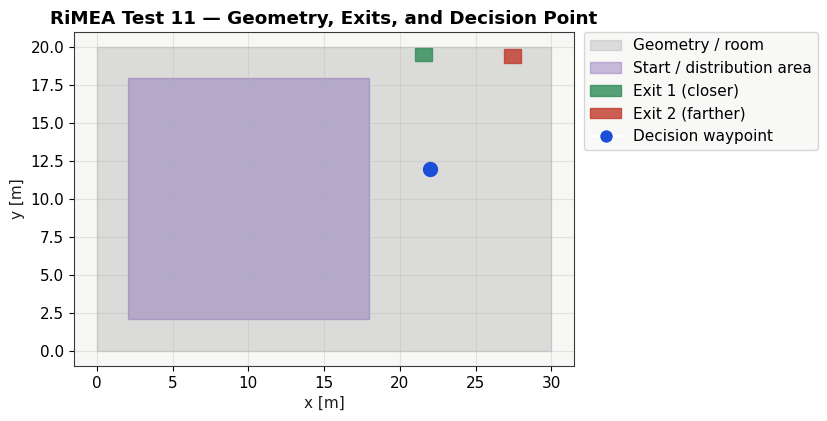

In [6]:
fig, ax = plt.subplots()

plot_polygon(geometry, ax=ax, color="#9b9b9b", alpha=0.3, add_points=False)
plot_polygon(distribution_poly, ax=ax, color="#7b5fb3", alpha=0.4, add_points=False)
plot_polygon(exit1_poly, ax=ax, color="#2e8b57", alpha=0.8, add_points=False)
plot_polygon(exit2_poly, ax=ax, color="#c0392b", alpha=0.8, add_points=False)

ax.plot(*decision_point, marker="o", color="#1d4ed8", markersize=10, zorder=5)

legend_handles = [
    mpatches.Patch(color="#9b9b9b", alpha=0.3, label="Geometry / room"),
    mpatches.Patch(color="#7b5fb3", alpha=0.4, label="Start / distribution area"),
    mpatches.Patch(color="#2e8b57", alpha=0.8, label="Exit 1 (closer)"),
    mpatches.Patch(color="#c0392b", alpha=0.8, label="Exit 2 (farther)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#1d4ed8",
               markersize=10, label="Decision waypoint"),
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

ax.set_aspect("equal")
ax.set_title("RiMEA Test 11 — Geometry, Exits, and Decision Point")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.tight_layout()
plt.show()

## Output Analysis

In [7]:
conn = sqlite3.connect("rimea11_output.sqlite")
df = pd.read_sql("SELECT * FROM trajectory_data", conn)

# Get each agent's LAST recorded frame (position right before they exited/disappeared)
last_positions = df.sort_values("frame").groupby("id").tail(1)

def classify_exit(row):
    p = Point(row["pos_x"], row["pos_y"])
    if exit1_poly.buffer(0.5).contains(p):
        return "exit_1"
    elif exit2_poly.buffer(0.5).contains(p):
        return "exit_2"
    else:
        return "unknown"

last_positions["exit_used"] = last_positions.apply(classify_exit, axis=1)

counts = last_positions["exit_used"].value_counts()
pct = (counts / counts.sum() * 100).round(1)

print(counts)
print(pct)

n_unknown = (last_positions["exit_used"] == "unknown").sum()
if n_unknown > 0:
    print(f"Warning: {n_unknown} agents never reached an exit polygon — "
          f"check max_simulation_time or exit buffer size")

exit_used
exit_1    807
exit_2    193
Name: count, dtype: int64
exit_used
exit_1    80.7
exit_2    19.3
Name: count, dtype: float64


## Acceptance 

In [10]:
assert counts.get("exit_1",0) > counts.get("exit_2",0)
assert counts.get("exit_1",0)/len(last_positions) >= 0.55
if counts.get("unknown",0) > 0:
    pct_unknown=counts.get("unknown",0)/len(last_positions)*100
    print(f"Note: {pct_unknown:.1f}% of agents did not reach an exit within "
              f"the simulated time -- possible congestion/jam at exit_1, "
              f"consistent with RiMEA 11's expectation of congestion.")
os.remove("rimea11_output.sqlite")